## Exercício II

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt 

In [3]:
R = np.pi                 # raio (inches) — entra implicitamente
T0 = 37.0                 # temperatura inicial (°C)
k = 5.58                  # difusividade térmica (inches^2 / hour)

t = np.linspace(0, 1, 500)   # de 0 a 1 hora

N = 1000
u_center = np.zeros_like(t)

for n in range(1, N + 1):
    u_center += 2 * T0 * (-1)**(n + 1) * np.exp(-n**2 * k * t)


[]

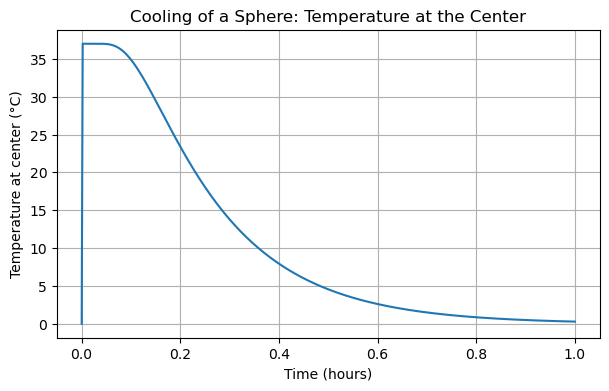

In [4]:
plt.figure(figsize=(7, 4))
plt.plot(t, u_center)
plt.xlabel("Time (hours)")
plt.ylabel("Temperature at center (°C)")
plt.title("Cooling of a Sphere: Temperature at the Center")
plt.grid(True)

plt.plot()

## Exercício III

In [5]:
R = np.pi
k = 5.58
h = 0.1
T0 = 37.0

def eigen_eq(lam):
    return np.tan(R * lam) - (R * lam) / (1 - R * h)

lambdas = []
n = 1
while len(lambdas) < 4:
    a = (n - 0.5) * np.pi / R
    b = (n + 0.5) * np.pi / R
    try:
        root = opt.brentq(eigen_eq, a, b)
        lambdas.append(root)
    except ValueError:
        pass
    n += 1

lambdas = np.array(lambdas)

def u_approx(rho, t):
    u = np.zeros_like(rho, dtype=float)
    for lam in lambdas:
        u += 37 * np.exp(-k * lam**2 * t) * np.sin(lam * rho) / rho
    return u

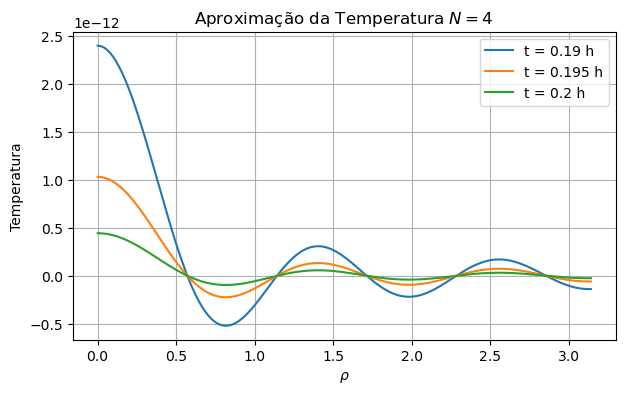

In [6]:
rho = np.linspace(1e-4, R, 400)

times = [0.19,0.195,0.2]


plt.figure(figsize=(7, 4))

for t_fixed in times:
    u = u_approx(rho, t_fixed)
    plt.plot(rho, u, label=f"t = {t_fixed} h")

plt.xlabel(r"$\rho$")
plt.ylabel("Temperatura")
plt.title("Aproximação da Temperatura $N=4$")
plt.grid(True)
plt.legend()


# plt.savefig("four_term_approximation.png")
# plt.close()

plt.show()